In [1]:
from IPython.display import HTML
from al_graph_research.data.datasets import GaussianDataset
import al_graph_research.visualization.visualizations as viz
from  al_graph_research.experiments.active_querying.active_querying_experiment import ActiveQueryingExperiment


In [2]:
mean1 = [.5, .4]
mean2 = [.8, -1.6]
mean3 = [-.4, .5]
mean_arr = [mean1, mean2, mean3]
cov = [[.1, 0], [0, .1]]
dataset = GaussianDataset(
    n_per_cluster=500,
    cov=cov,
    mean_arr=mean_arr,
    n_blobs=3,
    seed=42,
)

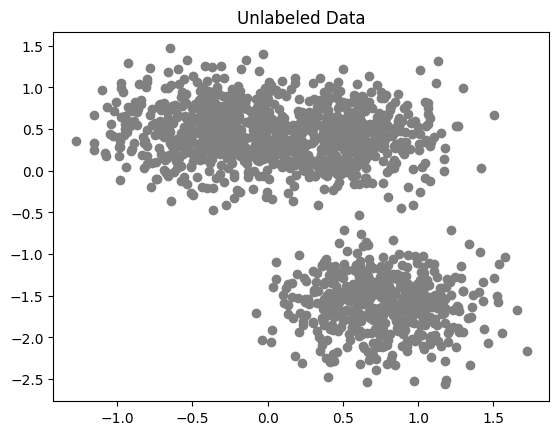

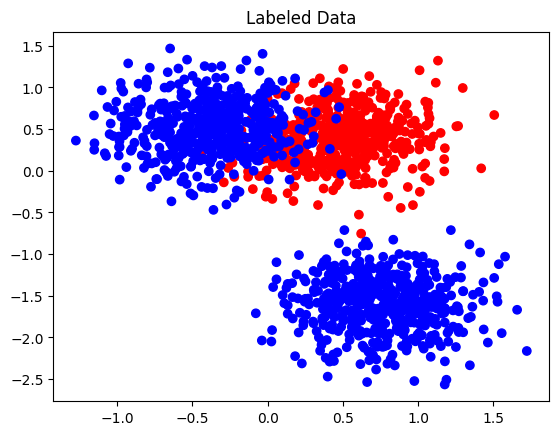

In [3]:
viz.dataset_visualization(dataset.data, dataset.labels)


In [4]:
exp_zero = ActiveQueryingExperiment(
    n_runs=3,
    accuracy_level=0.95,
    number_neighbors=30,
    num_starting_labels_per_class=1,
    num_queries_per_round=2,
    kernel="gaussian",
    alteration_strategy="zero",
    graph_construction_method="partner",
    max_iterations=500,
    starting_idx=1,
    ending_idx=3,
    empty_val=0    
)
exp_negate = ActiveQueryingExperiment(
    n_runs=3,
    accuracy_level=0.95,
    number_neighbors=30,
    num_starting_labels_per_class=1,
    num_queries_per_round=2,
    kernel="gaussian",
    alteration_strategy="negate",
    graph_construction_method="partner",
    max_iterations=500,
    starting_idx=1,
    ending_idx=3,
    empty_val=0    

)



In [5]:
results_zero = exp_zero.run(dataset)
results_negate = exp_negate.run(dataset)

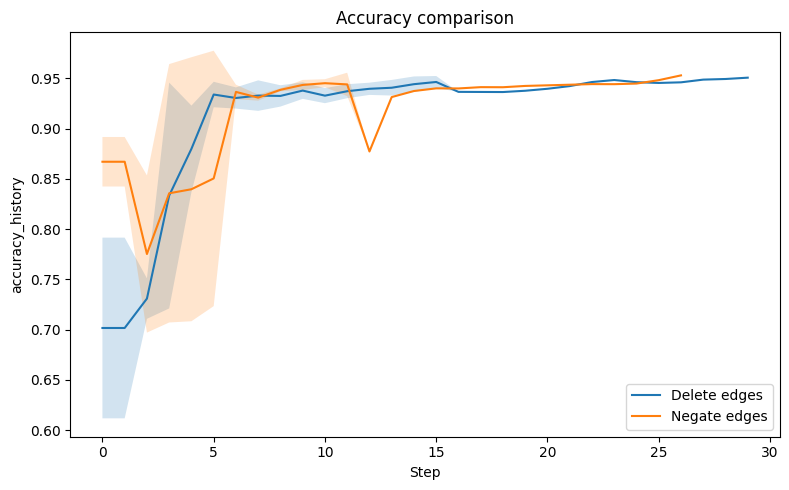

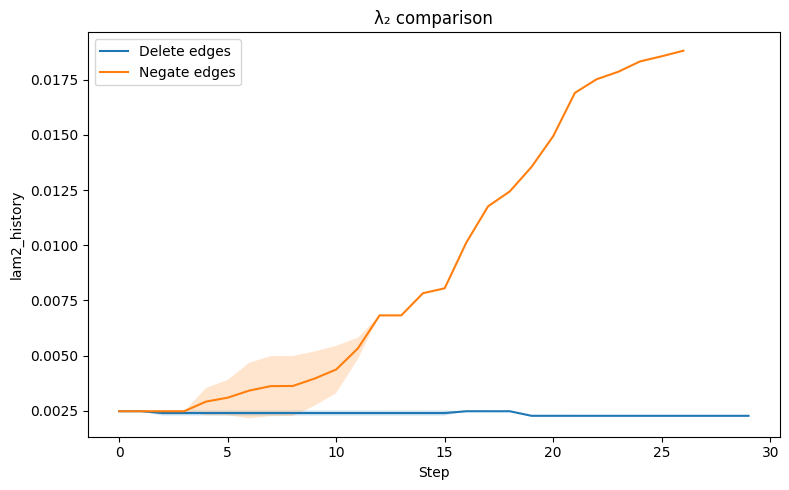

In [6]:
viz.plot_metric_comparison(
    [results_zero, results_negate],
    "accuracy_history",
    ["Delete edges", "Negate edges"],
    title="Accuracy comparison"
)

viz.plot_metric_comparison(
    [results_zero, results_negate],
    "lam2_history",
    ["Delete edges", "Negate edges"],
    title="λ₂ comparison"
)




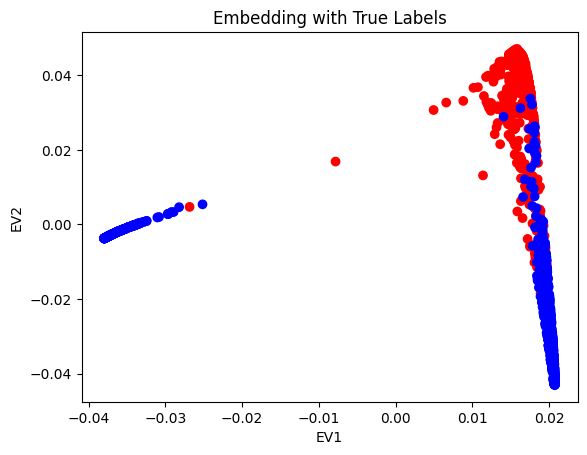

12
(1500, 2)


In [7]:
run = results_negate.runs[0]
run.embedding_history[0]
viz.plot_embedding_with_labels(run.embedding_history[0], dataset.labels)

print(len(run.embedding_history))
print(run.embedding_history[0].shape)

In [8]:
anim = viz.animate_embedding_history(run, dataset.labels)
HTML(anim.to_jshtml())

In [9]:
viz.animate_embedding_true_vs_pred
anim = viz.animate_embedding_true_vs_pred(run, dataset.labels)
HTML(anim.to_jshtml())